# TFG V5 — Domain-wall interference

This version proposes a different approach from V4. Instead of marking a window directly by its absolute cost `C(i)`, it looks at transitions between neighboring windows. The hypothesis is that, when occupied cells appear in blocks, the boundaries between bad and good regions contain useful information.

## Quantities used

For each window `i`:

```text
C(i) = number of ones in window_i
valid(i) = 1 if C(i)=0, and 0 otherwise
Delta C(i) = C(i+1) - C(i)
Delta valid(i) = valid(i+1) - valid(i)
```

A large change or a change in validity indicates a boundary, or `domain wall`, between regions with different behavior.

## Circuit flow

1. Prepare a uniform superposition over window indices.
2. Compute the cost and transition profile classically and modularly.
3. Encode a diagonal phase on `idx` according to the selected mode:
   - `delta_cost`
   - `descent`
   - `valid_boundary`
   - `oriented_valid`
4. Apply a local mixer over neighboring indices.
5. Repeat the block and analyze whether `P_valid`, `P_boundary`, or `P_near_valid` increases.

## Purpose of this version

V5 checks whether exploiting domain walls can be a useful preprocessing phase for finding valid or near-valid windows. It does not use Grover or global diffusion; it keeps the comparison with V4 by using the same type of local mixer.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", os.path.join(os.getcwd(), ".cache"))

from math import prod
import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import PhaseGate, UnitaryGate

print(qiskit.__version__)


2.3.1


In [2]:
# =========================================================
# Parameters configurables del experimento principal
# =========================================================

# Main 1D case with occupied blocks and a central free region.
D = 1
N = [8]
M = [2]
occupied_coords = [(0,), (1,), (2,), (6,), (7,)]

# Parameters de interferencia domain-wall.
theta = np.pi / 3
mixer_angle = 0.60
repetitions = 4
transition_mode = "oriented_valid"  # "delta_cost", "valid_boundary", "descent", "oriented_valid"

use_transition_phase = True
use_mixer = True
use_statevector_analysis = True
show_plots = True
mixer_method = "linear_valid"  # "local_geometric", "linear_valid", "rx_all"


## Implemented approach

In this version, the transition phase is implemented as a diagonal phase compiled directly on the `idx` register. Since the `grid` is fixed, the values `C(i)`, `valid(i)`, `Delta C(i)`, and `Delta valid(i)` are computed classically before building the circuit.

This keeps the notebook lightweight and easy to experiment with: it allows testing the `domain wall interference` hypothesis without adding reversible arithmetic for cost differences inside the circuit yet.

The mixer remains local. It can mix consecutive indices (`linear_valid`) or neighboring starting positions in the ND geometry (`local_geometric`). This avoids Grover-style global diffusion and keeps the approach comparable to V4.

In [3]:
# =========================================================
# ND geometry and classical utilities reutilizadas de V4
# =========================================================

def validate_problem(N, M):
    if len(N) != len(M):
        raise ValueError("N and M must have the same dimension.")
    for d, (n_d, m_d) in enumerate(zip(N, M)):
        if n_d <= 0 or m_d <= 0:
            raise ValueError(f"N[{d}] and M[{d}] must be positive.")
        if m_d > n_d:
            raise ValueError(f"M[{d}] cannot be greater than N[{d}].")


def coord_to_index(coord, dims):
    """Converts ND coordinates to a row-major linear index."""
    idx_lin = 0
    stride = 1
    for d in reversed(range(len(dims))):
        idx_lin += coord[d] * stride
        stride *= dims[d]
    return idx_lin


def index_to_coord(index, dims):
    """Converts a row-major linear index to ND coordinates."""
    coord = [0] * len(dims)
    rem = index
    for d in reversed(range(len(dims))):
        coord[d] = rem % dims[d]
        rem //= dims[d]
    return tuple(coord)


def valid_starts_nd(N, M):
    """Valid starting coordinates for a window M inside N."""
    return list(np.ndindex(tuple(N[d] - M[d] + 1 for d in range(len(N)))))


def window_qubits_nd(start, N, M):
    """Linear indices of the cells covered by the window starting at start."""
    qubits = []
    for offset in np.ndindex(tuple(M)):
        coord = tuple(start[d] + offset[d] for d in range(len(N)))
        qubits.append(coord_to_index(coord, N))
    return qubits


def normalize_coord(coord, D):
    if D == 1 and isinstance(coord, int):
        return (coord,)
    return tuple(coord)


def build_grid_bits(N, occupied_coords):
    """Returns a classical vector with 1 on occupied cells and 0 on free cells."""
    D = len(N)
    grid = [0] * prod(N)
    for raw_coord in occupied_coords:
        coord = normalize_coord(raw_coord, D)
        if len(coord) != D:
            raise ValueError(f"Coordinate {coord} does not have dimension {D}.")
        for d, x in enumerate(coord):
            if x < 0 or x >= N[d]:
                raise ValueError(f"Coordinate {coord} is outside the grid N={N}.")
        grid[coord_to_index(coord, N)] = 1
    return grid


def compute_window_cost_classical(grid_bits, start, N, M):
    """C(i): number of ones in the window associated with start."""
    return sum(grid_bits[q] for q in window_qubits_nd(start, N, M))


def window_string_classical(grid_bits, start, N, M):
    return ''.join(str(grid_bits[q]) for q in window_qubits_nd(start, N, M))


def valid_indicator(cost):
    return 1 if cost == 0 else 0


def get_valid_indices(grid_bits, starts, N, M):
    return [i for i, start in enumerate(starts) if compute_window_cost_classical(grid_bits, start, N, M) == 0]


def gray_order_valid(W, IDX):
    gray_full = [t ^ (t >> 1) for t in range(2**IDX)]
    return [g for g in gray_full if g < W]


def format_nd_array_from_bits(bitstring, dims):
    arr = np.array(list(bitstring), dtype=str).reshape(tuple(dims))
    return np.array2string(arr, separator=' ').replace("'", "")


In [4]:
# =========================================================
# Domain walls: costs, transitions, and phase profiles
# =========================================================

def compute_costs_and_valids(grid_bits, starts, N, M):
    costs = [compute_window_cost_classical(grid_bits, start, N, M) for start in starts]
    valids = [valid_indicator(c) for c in costs]
    return costs, valids


def transition_features(costs, valids):
    """Computes Delta C(i), Delta valid(i), and boundary flags by index."""
    W = len(costs)
    delta_cost = [None] * W
    delta_valid = [None] * W
    edge_boundary = [False] * W
    boundary_index = [False] * W

    for i in range(W - 1):
        delta_cost[i] = costs[i + 1] - costs[i]
        delta_valid[i] = valids[i + 1] - valids[i]
        edge_boundary[i] = valids[i + 1] != valids[i]
        if edge_boundary[i]:
            boundary_index[i] = True
            boundary_index[i + 1] = True

    near_valid = [c <= 1 for c in costs]
    return {
        "delta_cost": delta_cost,
        "delta_valid": delta_valid,
        "edge_boundary": edge_boundary,
        "boundary_index": boundary_index,
        "near_valid": near_valid,
    }


def transition_phase_profile(costs, valids, theta, transition_mode):
    """
    Returns a phase phi_i for each index i.

    Modos:
    - delta_cost: phi_i = theta * (C(i+1)-C(i)).
    - descent: phi_i = +theta if C decreases toward i+1, -theta if it increases.
    - valid_boundary: phi_i = theta if i is on a validity boundary.
    - oriented_valid: phi_i = +theta for invalid indices neighboring valid ones,
      and -theta for valid indices on the boundary.
    """
    features = transition_features(costs, valids)
    W = len(costs)
    phases = [0.0] * W

    if transition_mode == "delta_cost":
        for i, dc in enumerate(features["delta_cost"]):
            phases[i] = 0.0 if dc is None else theta * dc

    elif transition_mode == "descent":
        for i, dc in enumerate(features["delta_cost"]):
            if dc is None or dc == 0:
                phases[i] = 0.0
            elif dc < 0:
                phases[i] = theta
            else:
                phases[i] = -theta

    elif transition_mode == "valid_boundary":
        for i, is_boundary in enumerate(features["boundary_index"]):
            phases[i] = theta if is_boundary else 0.0

    elif transition_mode == "oriented_valid":
        for i in range(W):
            has_valid_neighbor = False
            has_invalid_neighbor = False
            for j in (i - 1, i + 1):
                if 0 <= j < W:
                    has_valid_neighbor |= valids[j] == 1
                    has_invalid_neighbor |= valids[j] == 0
            if valids[i] == 0 and has_valid_neighbor:
                phases[i] = theta
            elif valids[i] == 1 and has_invalid_neighbor:
                phases[i] = -theta
            else:
                phases[i] = 0.0

    else:
        raise ValueError(
            "transition_mode debe ser 'delta_cost', 'valid_boundary', 'descent' u 'oriented_valid'."
        )

    return phases, features


def boundary_indices_from_features(features):
    return [i for i, is_boundary in enumerate(features["boundary_index"]) if is_boundary]


def near_valid_indices_from_features(features):
    return [i for i, is_near in enumerate(features["near_valid"]) if is_near]


In [5]:
# =========================================================
# Quantum blocks: transition phase + local mixer
# =========================================================

def prepare_valid_index_superposition(qc, idx, W):
    """Prepares 1/sqrt(W) sum_{i=0}^{W-1} |i>, even when W is not a power of 2."""
    IDX = len(idx)
    amps = np.zeros(2**IDX, dtype=complex)
    amps[:W] = 1 / np.sqrt(W)
    qc.initialize(amps, idx)


def apply_phase_to_basis_state(qc, idx, basis_state, angle):
    """Applies exp(i angle) to the computational state |basis_state> of the idx register."""
    if abs(angle) < 1e-15:
        return

    IDX = len(idx)
    zero_qubits = [q for bit, q in enumerate(idx) if ((basis_state >> bit) & 1) == 0]
    for q in zero_qubits:
        qc.x(q)

    if IDX == 1:
        qc.p(angle, idx[0])
    else:
        gate = PhaseGate(angle).control(IDX - 1)
        qc.append(gate, list(idx[:-1]) + [idx[-1]])

    for q in reversed(zero_qubits):
        qc.x(q)


def apply_transition_phase(qc, idx, phases, W, label="U_DW"):
    """Applies a diagonal phase compiled from the domain-wall profile."""
    for i in range(W):
        apply_phase_to_basis_state(qc, idx, i, phases[i])
    qc.barrier(label=label)


def two_level_mixer_gate(num_qubits, a, b, beta, label=None):
    """Local rotation exp(-i beta X_ab) in span{|a>, |b>}."""
    dim = 2**num_qubits
    U = np.eye(dim, dtype=complex)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    U[a, a] = c
    U[b, b] = c
    U[a, b] = s
    U[b, a] = s
    return UnitaryGate(U, label=label or f"Mix({a},{b})")


def mixer_edges_from_starts(starts, N, method="local_geometric"):
    """Local edges between valid indices. Does not implement Grover global diffusion."""
    if method == "linear_valid":
        return [(i, i + 1) for i in range(len(starts) - 1)]

    if method != "local_geometric":
        raise ValueError("Unknown local mixer method.")

    start_to_idx = {tuple(s): i for i, s in enumerate(starts)}
    edges = []
    D = len(N)
    for i, start in enumerate(starts):
        for d in range(D):
            neigh = list(start)
            neigh[d] += 1
            neigh = tuple(neigh)
            if neigh in start_to_idx:
                edges.append((i, start_to_idx[neigh]))
    return edges


def apply_local_mixer(qc, idx, starts, N, mixer_angle, method="local_geometric"):
    """
    Modular local mixer on idx.
    - local_geometric: mixes neighboring starting positions in the ND grid.
    - linear_valid: mixes consecutive indices.
    - rx_all: prototipo simple; puede filtrar amplitud a estados idx >= W si W no es potencia de 2.
    """
    if abs(mixer_angle) < 1e-15:
        return

    if method == "rx_all":
        for q in idx:
            qc.rx(2 * mixer_angle, q)
        return

    IDX = len(idx)
    for a, b in mixer_edges_from_starts(starts, N, method):
        qc.append(two_level_mixer_gate(IDX, a, b, mixer_angle), list(idx))


In [6]:
# =========================================================
# Circuit construction, analysis, and visualization
# =========================================================

def build_domain_wall_circuit(
    N, M, occupied_coords, theta, mixer_angle, repetitions,
    transition_mode="oriented_valid",
    use_transition_phase=True,
    use_mixer=True,
    mixer_method="local_geometric",
    add_barriers=True,
):
    validate_problem(N, M)
    starts = valid_starts_nd(N, M)
    W = len(starts)
    IDX = int(np.ceil(np.log2(W))) if W > 1 else 1
    grid_bits = build_grid_bits(N, occupied_coords)
    costs, valids = compute_costs_and_valids(grid_bits, starts, N, M)
    phases, features = transition_phase_profile(costs, valids, theta, transition_mode)

    idx = QuantumRegister(IDX, "i")
    qc = QuantumCircuit(idx)
    prepare_valid_index_superposition(qc, idx, W)
    if add_barriers:
        qc.barrier(label="init")

    for r in range(repetitions):
        if use_transition_phase:
            apply_transition_phase(qc, idx, phases, W, label=f"U_DW[{r}]")
        if use_mixer:
            apply_local_mixer(qc, idx, starts, N, mixer_angle, method=mixer_method)
        if add_barriers:
            qc.barrier(label=f"layer {r}")

    metadata = {
        "N": list(N),
        "M": list(M),
        "D": len(N),
        "starts": starts,
        "W": W,
        "IDX": IDX,
        "grid_bits": grid_bits,
        "occupied_coords": [normalize_coord(c, len(N)) for c in occupied_coords],
        "costs": costs,
        "valids": valids,
        "phases": phases,
        "features": features,
        "theta": theta,
        "mixer_angle": mixer_angle,
        "repetitions": repetitions,
        "transition_mode": transition_mode,
        "mixer_method": mixer_method,
    }
    return qc, metadata


def index_probabilities_from_statevector(sv, metadata):
    IDX = metadata["IDX"]
    probs = np.zeros(2**IDX, dtype=float)
    idx_mask = (1 << IDX) - 1
    for basis_idx, amp in enumerate(sv.data):
        probs[basis_idx & idx_mask] += float(abs(amp) ** 2)
    return probs


def analyze_probabilities(sv, metadata, title="Domain-wall analysis", tol=1e-12):
    N, M = metadata["N"], metadata["M"]
    starts = metadata["starts"]
    W = metadata["W"]
    costs = metadata["costs"]
    valids = metadata["valids"]
    features = metadata["features"]
    grid_bits = metadata["grid_bits"]
    probs = index_probabilities_from_statevector(sv, metadata)

    valid_indices = [i for i, v in enumerate(valids) if v == 1]
    boundary_indices = boundary_indices_from_features(features)
    near_valid_indices = near_valid_indices_from_features(features)

    p_valid_initial = len(valid_indices) / W
    p_boundary_initial = len(boundary_indices) / W
    p_near_valid_initial = len(near_valid_indices) / W

    p_valid_after = float(sum(probs[i] for i in valid_indices))
    p_boundary_after = float(sum(probs[i] for i in boundary_indices))
    p_near_valid_after = float(sum(probs[i] for i in near_valid_indices))
    p_invalid_index_after = float(sum(probs[i] for i in range(W, len(probs))))

    print()
    print(f"============ {title} ============")
    print(f"N={N}, M={M}, W={W}, IDX={metadata['IDX']}")
    print(f"theta={metadata['theta']:.6g}, mixer_angle={metadata['mixer_angle']:.6g}, repetitions={metadata['repetitions']}")
    print(f"transition_mode={metadata['transition_mode']}, mixer_method={metadata['mixer_method']}")
    print(f"valid_indices={valid_indices}")
    print(f"boundary_indices={boundary_indices}")
    print(f"near_valid_indices={near_valid_indices}")
    print(f"P_valid_initial      = {p_valid_initial:.6f}")
    print(f"P_valid_after        = {p_valid_after:.6f}")
    print(f"P_boundary_initial   = {p_boundary_initial:.6f}")
    print(f"P_boundary_after     = {p_boundary_after:.6f}")
    print(f"P_near_valid_initial = {p_near_valid_initial:.6f}")
    print(f"P_near_valid_after   = {p_near_valid_after:.6f}")
    if p_invalid_index_after > tol:
        print(f"P_invalid_index_after = {p_invalid_index_after:.6f}")

    print()
    print("index | start coordinate | window | C(i) | valid(i) | Delta C | Delta valid | phase | probability")
    print("------|------------------|--------|------|----------|---------|-------------|-------|------------")
    for i, start in enumerate(starts):
        window = window_string_classical(grid_bits, start, N, M)
        dc = features["delta_cost"][i]
        dv = features["delta_valid"][i]
        dc_str = "-" if dc is None else str(dc)
        dv_str = "-" if dv is None else str(dv)
        print(
            f"{i:>5} | {str(start):<16} | {window:<6} | {costs[i]:>4} | {valids[i]:>8} | "
            f"{dc_str:>7} | {dv_str:>11} | {metadata['phases'][i]:>5.2f} | {probs[i]:>10.6f}"
        )

    return {
        "probs": probs,
        "P_valid_initial": p_valid_initial,
        "P_valid_after": p_valid_after,
        "P_boundary_initial": p_boundary_initial,
        "P_boundary_after": p_boundary_after,
        "P_near_valid_initial": p_near_valid_initial,
        "P_near_valid_after": p_near_valid_after,
        "P_invalid_index_after": p_invalid_index_after,
        "valid_indices": valid_indices,
        "boundary_indices": boundary_indices,
        "near_valid_indices": near_valid_indices,
    }


def plot_domain_wall_results(metadata, analysis, title="Domain-wall results"):
    W = metadata["W"]
    x = np.arange(W)
    initial_probs = np.ones(W) / W
    after_probs = analysis["probs"][:W]
    costs = np.array(metadata["costs"])
    valids = set(analysis["valid_indices"])
    boundaries = set(analysis["boundary_indices"])

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(title)

    axes[0, 0].bar(x - 0.18, initial_probs, width=0.36, label="inicial")
    axes[0, 0].bar(x + 0.18, after_probs, width=0.36, label="after")
    axes[0, 0].set_title("Probability by index")
    axes[0, 0].set_xlabel("index i")
    axes[0, 0].set_ylabel("probability")
    axes[0, 0].legend()

    axes[0, 1].plot(x, costs, marker="o")
    axes[0, 1].set_title("Coste C(i)")
    axes[0, 1].set_xlabel("index i")
    axes[0, 1].set_ylabel("C(i)")

    colors = ["tab:green" if i in valids else "tab:red" for i in x]
    axes[1, 0].bar(x, after_probs, color=colors, alpha=0.75)
    for i in boundaries:
        axes[1, 0].axvline(i, color="black", linestyle="--", alpha=0.45)
    axes[1, 0].set_title("Validos y fronteras")
    axes[1, 0].set_xlabel("index i")
    axes[1, 0].set_ylabel("final probability")

    labels = ["valid", "boundary", "near_valid"]
    initial = [analysis["P_valid_initial"], analysis["P_boundary_initial"], analysis["P_near_valid_initial"]]
    final = [analysis["P_valid_after"], analysis["P_boundary_after"], analysis["P_near_valid_after"]]
    pos = np.arange(len(labels))
    axes[1, 1].bar(pos - 0.18, initial, width=0.36, label="inicial")
    axes[1, 1].bar(pos + 0.18, final, width=0.36, label="after")
    axes[1, 1].set_xticks(pos)
    axes[1, 1].set_xticklabels(labels)
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].set_title("Metricas agregadas")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


def run_domain_wall_experiment(
    name, N, M, occupied_coords, theta, mixer_angle, repetitions,
    transition_mode="oriented_valid",
    mixer_method="local_geometric",
    use_transition_phase=True,
    use_mixer=True,
    use_statevector_analysis=True,
    show_plot=False,
):
    print()
    print("#" * 40)
    print(f"Experiment: {name}")
    print("#" * 40)

    qc, metadata = build_domain_wall_circuit(
        N=N,
        M=M,
        occupied_coords=occupied_coords,
        theta=theta,
        mixer_angle=mixer_angle,
        repetitions=repetitions,
        transition_mode=transition_mode,
        use_transition_phase=use_transition_phase,
        use_mixer=use_mixer,
        mixer_method=mixer_method,
    )

    analysis = None
    if use_statevector_analysis:
        sv = Statevector.from_instruction(qc)
        analysis = analyze_probabilities(sv, metadata, title=name)
        if show_plot:
            plot_domain_wall_results(metadata, analysis, title=name)

    return qc, metadata, analysis



########################################
Experiment: Main V5 domain-wall interference
########################################

============ Main V5 domain-wall interference ============
N=[8], M=[2], W=7, IDX=3
theta=1.0472, mixer_angle=0.6, repetitions=4
transition_mode=oriented_valid, mixer_method=linear_valid
valid_indices=[3, 4]
boundary_indices=[2, 3, 4, 5]
near_valid_indices=[2, 3, 4, 5]
P_valid_initial      = 0.285714
P_valid_after        = 0.593935
P_boundary_initial   = 0.571429
P_boundary_after     = 0.732702
P_near_valid_initial = 0.571429
P_near_valid_after   = 0.732702

index | start coordinate | window | C(i) | valid(i) | Delta C | Delta valid | phase | probability
------|------------------|--------|------|----------|---------|-------------|-------|------------
    0 | (0,)             | 11     |    2 |        0 |       0 |           0 |  0.00 |   0.066900
    1 | (1,)             | 11     |    2 |        0 |      -1 |           0 |  0.00 |   0.155292
    2 | (2,)      

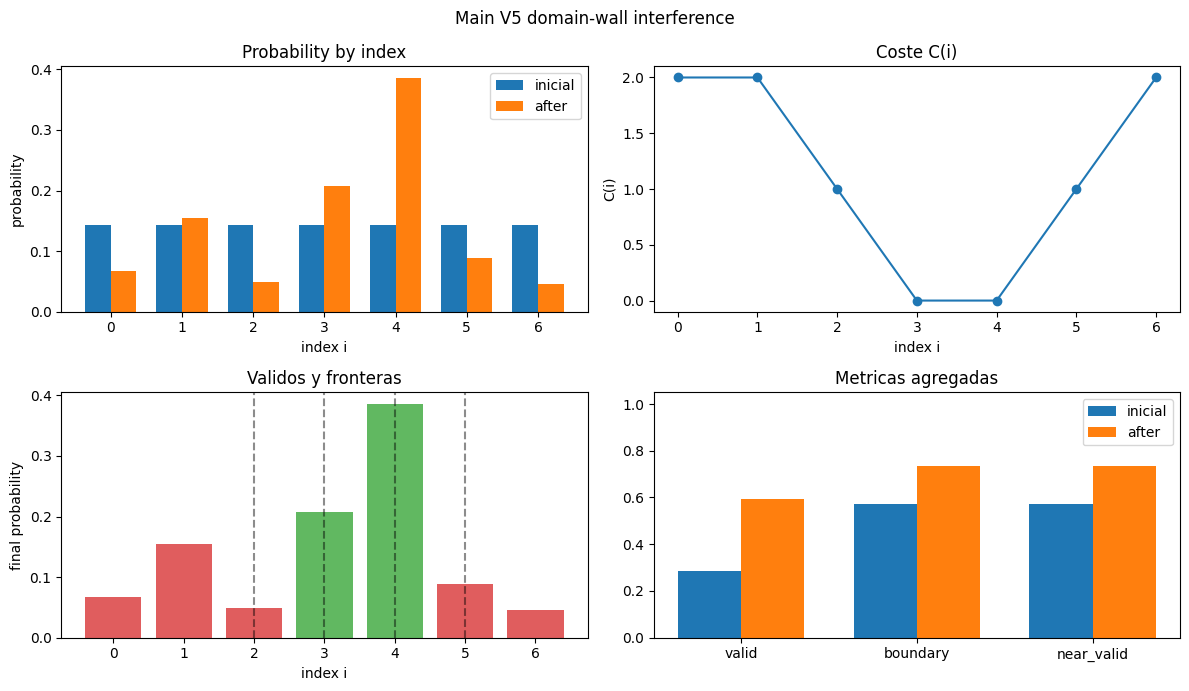

┌────────────────────────────────────────────────────────────────────────┐»
i_0: ┤0                                                                       ├»
     │                                                                        │»
i_1: ┤1 Initialize(0.37796,0.37796,0.37796,0.37796,0.37796,0.37796,0.37796,0) ├»
     │                                                                        │»
i_2: ┤2                                                                       ├»
     └────────────────────────────────────────────────────────────────────────┘»
«      init ┌───┐         ┌───┐               ┌───┐          ┌───┐     »
«i_0: ──░───┤ X ├─■───────┤ X ├──────■────────┤ X ├─■────────┤ X ├─────»
«       ░   └───┘ │       └───┘      │        ├───┤ │        ├───┤┌───┐»
«i_1: ──░─────────■──────────────────■────────┤ X ├─■────────┤ X ├┤ X ├»
«       ░   ┌───┐ │P(π/3) ┌───┐┌───┐ │P(-π/3) ├───┤ │P(-π/3) └───┘└───┘»
«i_2: ──░───┤ X ├─■───────┤ X ├┤ X ├─■────────┤ X ├─■──────────────────»
«       ░   └───┘         └───┘└───┘          └───┘                    »
«                    U_DW[0] ┌───────────┐┌───────────┐┌───────────┐»
«i_0: ─■────────────────░────┤0          ├┤0          ├┤0          ├»
«      │       ┌───┐    ░    │           ││           ││           │»
«i_1: ─■───────┤ X ├────░────┤1 Mix(0,1) ├┤1 Mix(1,2) ├┤1 Mix(2,3) ├»
«      │P(π/3) └───┘    ░    │           ││           ││           │»
«i_2: ─■────────────────░────┤2          ├┤2          ├┤2          ├»
«                       ░    └───────────┘└───────────┘└───────────┘»
«     ┌───────────┐┌───────────┐┌───────────┐ layer 0 ┌───┐         ┌───┐     »
«i_0: ┤0          ├┤0          ├┤0          ├────░────┤ X ├─■───────┤ X ├─────»
«     │           ││           ││           │    ░    └───┘ │       └───┘     »
«i_1: ┤1 Mix(3,4) ├┤1 Mix(4,5) ├┤1 Mix(5,6) ├────░──────────■─────────────────»
«     │           ││           ││           │    ░    ┌───┐ │P(π/3) ┌───┐┌───┐»
«i_2: ┤2          ├┤2          ├┤2          ├────░────┤ X ├─■───────┤ X ├┤ X ├»
«     └───────────┘└───────────┘└───────────┘    ░    └───┘         └───┘└───┘»
«               ┌───┐          ┌───┐                    U_DW[1] ┌───────────┐»
«i_0: ─■────────┤ X ├─■────────┤ X ├──────■────────────────░────┤0          ├»
«      │        ├───┤ │        ├───┤┌───┐ │       ┌───┐    ░    │           │»
«i_1: ─■────────┤ X ├─■────────┤ X ├┤ X ├─■───────┤ X ├────░────┤1 Mix(0,1) ├»
«      │P(-π/3) ├───┤ │P(-π/3) └───┘└───┘ │P(π/3) └───┘    ░    │           │»
«i_2: ─■────────┤ X ├─■───────────────────■────────────────░────┤2          ├»
«               └───┘                                      ░    └───────────┘»
«     ┌───────────┐┌───────────┐┌───────────┐┌───────────┐┌───────────┐»
«i_0: ┤0          ├┤0          ├┤0          ├┤0          ├┤0          ├»
«     │           ││           ││           ││           ││           │»
«i_1: ┤1 Mix(1,2) ├┤1 Mix(2,3) ├┤1 Mix(3,4) ├┤1 Mix(4,5) ├┤1 Mix(5,6) ├»
«     │           ││           ││           ││           ││           │»
«i_2: ┤2          ├┤2          ├┤2          ├┤2          ├┤2          ├»
«     └───────────┘└───────────┘└───────────┘└───────────┘└───────────┘»
«      layer 1 ┌───┐         ┌───┐               ┌───┐          ┌───┐     »
«i_0: ────░────┤ X ├─■───────┤ X ├──────■────────┤ X ├─■────────┤ X ├─────»
«         ░    └───┘ │       └───┘      │        ├───┤ │        ├───┤┌───┐»
«i_1: ────░──────────■──────────────────■────────┤ X ├─■────────┤ X ├┤ X ├»
«         ░    ┌───┐ │P(π/3) ┌───┐┌───┐ │P(-π/3) ├───┤ │P(-π/3) └───┘└───┘»
«i_2: ────░────┤ X ├─■───────┤ X ├┤ X ├─■────────┤ X ├─■──────────────────»
«         ░    └───┘         └───┘└───┘          └───┘                    »
«                    U_DW[2] ┌───────────┐┌───────────┐┌───────────┐»
«i_0: ─■────────────────░────┤0          ├┤0          ├┤0          ├»
«      │       ┌───┐    ░    │           ││           ││           │»
«i_1: ─■───────┤ X ├────░────┤1 Mix(0,1) ├┤1 Mix(1,2) ├┤1 Mix(2,3) ├»
«

In [7]:
# =========================================================
# Main experiment
# =========================================================

qc_v5, meta_v5, analysis_v5 = run_domain_wall_experiment(
    name="Main V5 domain-wall interference",
    N=N,
    M=M,
    occupied_coords=occupied_coords,
    theta=theta,
    mixer_angle=mixer_angle,
    repetitions=repetitions,
    transition_mode=transition_mode,
    mixer_method=mixer_method,
    use_transition_phase=use_transition_phase,
    use_mixer=use_mixer,
    use_statevector_analysis=use_statevector_analysis,
    show_plot=show_plots,
)

qc_v5.draw(output="text")


## Small tests

These cases check that the notebook runs in 1D and 2D, and that the domain-wall approach can measure whether `P_valid`, `P_boundary`, or `P_near_valid` increase. A universal improvement is not expected: the goal is to provide a modular benchmark for sweeping `theta`, `mixer_angle`, `repetitions`, and `transition_mode`.

In [8]:
# Test 1: 1D with clear blocks: invalid -> valid -> invalid
qc_test_block, meta_test_block, analysis_test_block = run_domain_wall_experiment(
    name="Test 1D domain wall: bloques",
    N=[8],
    M=[3],
    occupied_coords=[(0,), (1,), (2,), (6,), (7,)],
    theta=np.pi / 2,
    mixer_angle=0.30,
    repetitions=3,
    transition_mode="valid_boundary",
    mixer_method="linear_valid",
    show_plot=False,
)

# Test 2: 1D with several separated valid solutions
qc_test_multi_1d, meta_test_multi_1d, analysis_test_multi_1d = run_domain_wall_experiment(
    name="Test 1D domain wall: varias soluciones",
    N=[10],
    M=[2],
    occupied_coords=[(0,), (3,), (4,), (8,), (9,)],
    theta=np.pi / 3,
    mixer_angle=0.35,
    repetitions=3,
    transition_mode="oriented_valid",
    mixer_method="linear_valid",
    show_plot=False,
)

# Test 3: small 2D case with a 2x2 window
qc_test_2d, meta_test_2d, analysis_test_2d = run_domain_wall_experiment(
    name="2D domain-wall test: 4x4 with 2x2 window",
    N=[4, 4],
    M=[2, 2],
    occupied_coords=[(0, 0), (0, 1), (1, 0), (3, 3), (3, 2), (2, 3)],
    theta=np.pi / 6,
    mixer_angle=0.25,
    repetitions=2,
    transition_mode="descent",
    mixer_method="local_geometric",
    show_plot=False,
)



########################################
Experiment: Test 1D domain wall: bloques
########################################

============ Test 1D domain wall: bloques ============
N=[8], M=[3], W=6, IDX=3
theta=1.5708, mixer_angle=0.3, repetitions=3
transition_mode=valid_boundary, mixer_method=linear_valid
valid_indices=[3]
boundary_indices=[2, 3, 4]
near_valid_indices=[2, 3, 4]
P_valid_initial      = 0.166667
P_valid_after        = 0.256956
P_boundary_initial   = 0.500000
P_boundary_after     = 0.402469
P_near_valid_initial = 0.500000
P_near_valid_after   = 0.402469

index | start coordinate | window | C(i) | valid(i) | Delta C | Delta valid | phase | probability
------|------------------|--------|------|----------|---------|-------------|-------|------------
    0 | (0,)             | 111    |    3 |        0 |      -1 |           0 |  0.00 |   0.224243
    1 | (1,)             | 110    |    2 |        0 |      -1 |           0 |  0.00 |   0.106459
    2 | (2,)             | 100    |

## Design notes

- `TFG_V5` does not use Grover or a global diffusion operator. Interference appears by combining domain-wall phases with a local mixer.
- The transition phase is encoded as a diagonal phase on `idx`, using costs computed from the fixed grid. This is a compact oracle-like version used to test the hypothesis before implementing full reversible arithmetic for `Delta C`.
- `P_boundary_after` measures whether the circuit concentrates amplitude on boundaries between valid and invalid regions. `P_near_valid_after` measures whether it concentrates amplitude on windows with `C(i)<=1`, which can be useful near-solution candidates.
- The modes `delta_cost`, `descent`, `valid_boundary`, and `oriented_valid` allow comparing different interpretations of a domain wall.

## Analysis 1 — P_valid vs repetitions (oscillation curve)


In [9]:
# =========================================================
# Analysis helpers — V5
# =========================================================
# SLOW: set ANALYSIS_FAST_MODE = False for quick previews on large grids.
# Full thesis mode uses repetitions 1..40 and a 20x20 heatmap grid.

import time
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "font.size": 12,
})

VALID_COLOR = "#2ecc71"
INVALID_COLOR = "#e74c3c"
BASELINE_COLOR = "0.45"

ANALYSIS_FAST_MODE = False
ANALYSIS_MAX_REPS = 20 if ANALYSIS_FAST_MODE else 40
ANALYSIS_GRID_POINTS = 10 if ANALYSIS_FAST_MODE else 20
ANALYSIS_THETA_POINTS = 30 if ANALYSIS_FAST_MODE else 60
ANALYSIS_MATRIX_ACCELERATION = True  # exact W-dimensional layer model; set False to force full circuit sweeps.

v5_analysis_results = {}


def v5_analysis_context():
    """Collects the problem definition from the current notebook state."""
    meta = globals().get("meta_v5")
    if meta is not None:
        N0 = list(meta.get("N", globals().get("N")))
        M0 = list(meta.get("M", globals().get("M")))
        starts0 = list(meta.get("starts", valid_starts_nd(N0, M0)))
        grid_bits0 = list(meta.get("grid_bits", build_grid_bits(N0, meta.get("occupied_coords", globals().get("occupied_coords", [])))))
        occupied0 = list(meta.get("occupied_coords", globals().get("occupied_coords", [])))
        mixer0 = meta.get("mixer_method", globals().get("mixer_method", "local_geometric"))
        theta0 = float(globals().get("theta", meta.get("theta", np.pi / 2)))
        beta0 = float(globals().get("mixer_angle", meta.get("mixer_angle", 0.35)))
        transition0 = meta.get("transition_mode", globals().get("transition_mode", "oriented_valid"))
    else:
        N0 = list(globals().get("N"))
        M0 = list(globals().get("M"))
        occupied0 = list(globals().get("occupied_coords", []))
        starts0 = valid_starts_nd(N0, M0)
        grid_bits0 = build_grid_bits(N0, occupied0)
        mixer0 = globals().get("mixer_method", "local_geometric")
        theta0 = float(globals().get("theta", np.pi / 2))
        beta0 = float(globals().get("mixer_angle", 0.35))
        transition0 = globals().get("transition_mode", "oriented_valid")

    costs0 = [compute_window_cost_classical(grid_bits0, s, N0, M0) for s in starts0]
    valid_indices0 = [i for i, c in enumerate(costs0) if c == 0]
    W0 = len(starts0)
    return {
        "N": N0,
        "M": M0,
        "occupied_coords": occupied0,
        "starts": starts0,
        "grid_bits": grid_bits0,
        "costs": costs0,
        "valid_indices": valid_indices0,
        "W": W0,
        "theta": theta0,
        "beta": beta0,
        "mixer_method": mixer0,
        "transition_mode": transition0,
        "P_uniform": len(valid_indices0) / W0 if W0 else 0.0,
    }


def v5_build_circuit(theta_value, beta_value, reps_value):
    ctx = v5_analysis_context()
    try:
        qc, meta = build_domain_wall_circuit(
            ctx["N"], ctx["M"], ctx["occupied_coords"],
            theta_value, beta_value, reps_value,
            transition_mode=ctx["transition_mode"],
            use_transition_phase=globals().get("use_transition_phase", True),
            use_mixer=globals().get("use_mixer", True),
            mixer_method=ctx["mixer_method"],
            add_barriers=False,
        )
        return qc, meta
    except Exception as exc:
        print(f"[V5] skipped circuit build for reps={reps_value}, theta={theta_value:.4g}, beta={beta_value:.4g}: {exc}")
        return None, None


def v5_index_probabilities_from_sv(sv, meta):
    try:
        return index_probabilities_from_statevector(sv, meta)
    except Exception:
        data = np.asarray(sv.data, dtype=complex)
        W0 = int(meta.get("W", len(data)))
        IDX0 = int(meta.get("IDX", int(np.ceil(np.log2(max(W0, 2))))))
        probs = np.zeros(2**IDX0, dtype=float)
        mask = (1 << IDX0) - 1
        for basis_idx, amp in enumerate(data):
            probs[basis_idx & mask] += float(abs(amp) ** 2)
        return probs


def v5_p_valid_from_probs(probs, valid_indices):
    return float(sum(probs[i] for i in valid_indices if i < len(probs)))


def v5_simulate_probs(theta_value, beta_value, reps_value):
    qc, meta = v5_build_circuit(theta_value, beta_value, reps_value)
    if qc is None:
        return None, None
    try:
        sv = Statevector.from_instruction(qc)
        return v5_index_probabilities_from_sv(sv, meta), meta
    except Exception as exc:
        print(f"[V5] skipped Statevector extraction: {exc}")
        return None, meta


def v5_two_level_matrix(W, a, b, beta):
    G = np.eye(W, dtype=complex)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    G[a, a] = c
    G[b, b] = c
    G[a, b] = s
    G[b, a] = s
    return G


def v5_phase_vector(theta_value):
    ctx = v5_analysis_context()
    costs0 = ctx["costs"]
    valids0 = [1 if c == 0 else 0 for c in costs0]
    phases0, _features0 = transition_phase_profile(costs0, valids0, theta_value, ctx["transition_mode"])
    return phases0


def v5_layer_matrix(theta_value, beta_value):
    ctx = v5_analysis_context()
    W0 = ctx["W"]
    if ctx["mixer_method"] == "rx_all":
        raise ValueError("The W-dimensional layer model is only valid for local two-level mixers, not rx_all.")
    phases0 = v5_phase_vector(theta_value)
    D = np.diag(np.exp(1j * np.asarray(phases0[:W0], dtype=float)))
    U_mix = np.eye(W0, dtype=complex)
    edges = mixer_edges_from_starts(ctx["starts"], ctx["N"], ctx["mixer_method"])
    for a, b in edges:
        U_mix = v5_two_level_matrix(W0, a, b, beta_value) @ U_mix
    return U_mix @ D


def v5_analytic_probs(theta_value, beta_value, reps_value):
    ctx = v5_analysis_context()
    W0 = ctx["W"]
    psi = np.ones(W0, dtype=complex) / np.sqrt(W0)
    U = v5_layer_matrix(theta_value, beta_value)
    for _ in range(int(reps_value)):
        psi = U @ psi
    return np.abs(psi) ** 2


def v5_p_valid_analytic(theta_value, beta_value, reps_value):
    ctx = v5_analysis_context()
    probs = v5_analytic_probs(theta_value, beta_value, reps_value)
    return v5_p_valid_from_probs(probs, ctx["valid_indices"])


def v5_savefig(fig, stem):
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{stem}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

# =========================================================
# Analysis 1 — P_valid vs repetitions (V5)
# =========================================================

ctx = v5_analysis_context()
reps_values = np.arange(1, ANALYSIS_MAX_REPS + 1)
p_valid_values = []
start_time = time.time()

for r in reps_values:
    try:
        if ANALYSIS_FAST_MODE and ANALYSIS_MATRIX_ACCELERATION:
            p_valid_values.append(v5_p_valid_analytic(ctx["theta"], ctx["beta"], int(r)))
            continue
        probs, meta = v5_simulate_probs(ctx["theta"], ctx["beta"], int(r))
        if probs is None:
            p_valid_values.append(np.nan)
            continue
        p_valid_values.append(v5_p_valid_from_probs(probs, ctx["valid_indices"]))
    except Exception as exc:
        print(f"[V5] repetition point skipped r={r}: {exc}")
        p_valid_values.append(np.nan)

p_valid_values = np.asarray(p_valid_values, dtype=float)
if np.all(np.isnan(p_valid_values)):
    print("[V5] Analysis 1 skipped: no valid simulation points.")
else:
    max_idx = int(np.nanargmax(p_valid_values))
    r_star = int(reps_values[max_idx])
    p_star = float(p_valid_values[max_idx])
    v5_analysis_results["oscillation"] = {
        "reps": reps_values,
        "p_valid": p_valid_values,
        "r_star": r_star,
        "p_star": p_star,
        "P_uniform": ctx["P_uniform"],
        "theta": ctx["theta"],
        "beta": ctx["beta"],
        "elapsed_s": time.time() - start_time,
        "source": "matrix" if (ANALYSIS_FAST_MODE and ANALYSIS_MATRIX_ACCELERATION) else "circuit Statevector",
    }

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(reps_values, p_valid_values, marker="o", linewidth=2, color=VALID_COLOR, label="P_valid")
    ax.axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    ax.axvline(r_star, color="black", linestyle=":", linewidth=1.5, label=f"r*={r_star}")
    ax.annotate(f"max={p_star:.3f}", xy=(r_star, p_star), xytext=(r_star + 1, min(1.0, p_star + 0.08)), arrowprops={"arrowstyle": "->", "lw": 1.0})
    ax.set_xlabel("repetitions r")
    ax.set_ylabel("P_valid")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"P_valid oscillation vs repetitions (theta={ctx['theta']:.3f}, beta={ctx['beta']:.3f})")
    ax.legend()
    fig.tight_layout()
    v5_savefig(fig, "v5_oscillation")
    print(f"[V5] Analysis 1 saved: v5_oscillation.pdf/png; r*={r_star}, P_valid={p_star:.6f}, elapsed={time.time()-start_time:.1f}s")


[V5] Analysis 1 saved: v5_oscillation.pdf/png; r*=37, P_valid=0.810867, elapsed=8.4s


## Analysis 2 — 2D heatmap: P_valid(theta, beta) at fixed r*


In [10]:
# =========================================================
# Analysis 2 — 2D heatmap P_valid(theta, beta) (V5)
# =========================================================

ctx = v5_analysis_context()
r_star = v5_analysis_results.get("oscillation", {}).get("r_star", 4)
theta_values = np.linspace(0, np.pi, ANALYSIS_GRID_POINTS)
beta_values = np.linspace(0, np.pi / 2, ANALYSIS_GRID_POINTS)
heatmap = np.full((len(theta_values), len(beta_values)), np.nan, dtype=float)
start_time = time.time()

for it, th in enumerate(theta_values):
    for ib, be in enumerate(beta_values):
        try:
            if ANALYSIS_MATRIX_ACCELERATION:
                heatmap[it, ib] = v5_p_valid_analytic(th, be, r_star)
            else:
                probs, _meta = v5_simulate_probs(th, be, r_star)
                if probs is not None:
                    heatmap[it, ib] = v5_p_valid_from_probs(probs, ctx["valid_indices"])
        except Exception as exc:
            print(f"[V5] heatmap point skipped theta={th:.4g}, beta={be:.4g}: {exc}")

if np.all(np.isnan(heatmap)):
    print("[V5] Analysis 2 skipped: heatmap is empty.")
else:
    max_pos = np.unravel_index(np.nanargmax(heatmap), heatmap.shape)
    theta_star_heat = float(theta_values[max_pos[0]])
    beta_star_heat = float(beta_values[max_pos[1]])
    p_star_heat = float(heatmap[max_pos])
    v5_analysis_results["heatmap"] = {
        "theta_values": theta_values,
        "beta_values": beta_values,
        "heatmap": heatmap,
        "theta_star": theta_star_heat,
        "beta_star": beta_star_heat,
        "p_star": p_star_heat,
        "r_star": r_star,
    }

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(
        heatmap,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=[beta_values[0] / np.pi, beta_values[-1] / np.pi, theta_values[0] / np.pi, theta_values[-1] / np.pi],
    )
    ax.scatter([beta_star_heat / np.pi], [theta_star_heat / np.pi], marker="*", s=160, color="white", edgecolor="black", linewidth=0.8, label="global max")
    ax.set_xlabel("beta / pi")
    ax.set_ylabel("theta / pi")
    ax.set_title(f"P_valid heatmap at r={r_star} — V5")
    ax.legend(loc="upper right")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P_valid")
    fig.tight_layout()
    v5_savefig(fig, "v5_heatmap")
    print(f"[V5] Analysis 2 saved: v5_heatmap.pdf/png; theta*={theta_star_heat:.4f}, beta*={beta_star_heat:.4f}, P_valid={p_star_heat:.6f}, elapsed={time.time()-start_time:.1f}s")


[V5] Analysis 2 saved: v5_heatmap.pdf/png; theta*=0.6614, beta*=0.5787, P_valid=0.728906, elapsed=1.5s


## Analysis 3 — Eigenvalue spectrum and period prediction (Method 2)


In [11]:
# =========================================================
# Analysis 3 — Eigenvalue spectrum and period prediction (V5)
# =========================================================

ctx = v5_analysis_context()
try:
    U_layer = v5_layer_matrix(ctx["theta"], ctx["beta"])
    eigvals, eigvecs = np.linalg.eig(U_layer)
    unit_t = np.linspace(0, 2 * np.pi, 400)

    analytical_reps = np.arange(1, 61)
    psi = np.ones(ctx["W"], dtype=complex) / np.sqrt(ctx["W"])
    analytical_curve = []
    psi_r = psi.copy()
    for _r in analytical_reps:
        psi_r = U_layer @ psi_r
        analytical_curve.append(v5_p_valid_from_probs(np.abs(psi_r) ** 2, ctx["valid_indices"]))
    analytical_curve = np.asarray(analytical_curve)

    osc = v5_analysis_results.get("oscillation", {})
    v5_analysis_results["spectrum"] = {
        "U_layer": U_layer,
        "eigvals": eigvals,
        "analytical_reps": analytical_reps,
        "analytical_curve": analytical_curve,
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(np.cos(unit_t), np.sin(unit_t), color="0.6", linewidth=1.2, label="unit circle")
    sc = axes[0].scatter(eigvals.real, eigvals.imag, c=eigvals.imag, cmap="viridis", s=55, zorder=3)
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].set_xlabel("Re(lambda)")
    axes[0].set_ylabel("Im(lambda)")
    axes[0].set_title(f"Eigenvalue spectrum of one layer — V5")
    axes[0].legend()
    fig.colorbar(sc, ax=axes[0], label="Im(lambda)")

    axes[1].plot(analytical_reps, analytical_curve, color="black", linewidth=2, label="matrix prediction")
    if osc:
        axes[1].plot(osc["reps"], osc["p_valid"], marker="o", linestyle="none", color=VALID_COLOR, label="circuit Statevector")
        axes[1].axhline(osc["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    axes[1].set_xlabel("repetitions r")
    axes[1].set_ylabel("P_valid")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Analytical period prediction")
    axes[1].legend()

    fig.tight_layout()
    v5_savefig(fig, "v5_spectrum")
    print(f"[V5] Analysis 3 saved: v5_spectrum.pdf/png")
except Exception as exc:
    print(f"[V5] Analysis 3 skipped: {exc}")


[V5] Analysis 3 saved: v5_spectrum.pdf/png


## Analysis 4 — Optimal angle scan: P_valid vs theta at fixed beta and r*


In [12]:
# =========================================================
# Analysis 4 — Optimal angle scan P_valid(theta) (V5)
# =========================================================

ctx = v5_analysis_context()
r_star = v5_analysis_results.get("oscillation", {}).get("r_star", 4)
theta_scan_values = np.linspace(0, 2 * np.pi, ANALYSIS_THETA_POINTS)
theta_scan = np.full(len(theta_scan_values), np.nan, dtype=float)
start_time = time.time()

for i, th in enumerate(theta_scan_values):
    try:
        if ANALYSIS_MATRIX_ACCELERATION:
            theta_scan[i] = v5_p_valid_analytic(th, ctx["beta"], r_star)
        else:
            probs, _meta = v5_simulate_probs(th, ctx["beta"], r_star)
            if probs is not None:
                theta_scan[i] = v5_p_valid_from_probs(probs, ctx["valid_indices"])
    except Exception as exc:
        print(f"[V5] theta point skipped theta={th:.4g}: {exc}")

if np.all(np.isnan(theta_scan)):
    print("[V5] Analysis 4 skipped: theta scan is empty.")
else:
    max_idx = int(np.nanargmax(theta_scan))
    theta_star_scan = float(theta_scan_values[max_idx])
    p_star_scan = float(theta_scan[max_idx])
    v5_analysis_results["theta_scan"] = {
        "theta_values": theta_scan_values,
        "p_valid": theta_scan,
        "theta_star": theta_star_scan,
        "p_star": p_star_scan,
        "r_star": r_star,
        "beta": ctx["beta"],
    }

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(theta_scan_values / np.pi, theta_scan, color=VALID_COLOR, linewidth=2, label="P_valid")
    ax.axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    ax.axvline(theta_star_scan / np.pi, color="black", linestyle=":", linewidth=1.5, label=f"theta*={theta_star_scan/np.pi:.2f} pi")
    ax.annotate(f"max={p_star_scan:.3f}", xy=(theta_star_scan / np.pi, p_star_scan), xytext=(theta_star_scan / np.pi + 0.08, min(1.0, p_star_scan + 0.08)), arrowprops={"arrowstyle": "->", "lw": 1.0})
    ax.set_xlabel("theta / pi")
    ax.set_ylabel("P_valid")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"P_valid vs theta at beta={ctx['beta']:.3f}, r={r_star} — V5")
    ax.legend()
    fig.tight_layout()
    v5_savefig(fig, "v5_theta_scan")
    print(f"[V5] Analysis 4 saved: v5_theta_scan.pdf/png; theta*={theta_star_scan:.4f}, P_valid={p_star_scan:.6f}, elapsed={time.time()-start_time:.1f}s")


[V5] Analysis 4 saved: v5_theta_scan.pdf/png; theta*=0.8520, P_valid=0.761454, elapsed=0.7s


## Analysis 5 — Summary dashboard


In [13]:
# =========================================================
# Analysis 5 — Summary dashboard (V5)
# =========================================================

ctx = v5_analysis_context()
try:
    osc = v5_analysis_results.get("oscillation")
    hm = v5_analysis_results.get("heatmap")
    scan = v5_analysis_results.get("theta_scan")
    if osc is None or hm is None or scan is None:
        raise RuntimeError("Run analyses 1, 2 and 4 before the dashboard.")

    r_star = int(osc["r_star"])
    theta_opt = float(scan["theta_star"])
    beta_opt = float(hm["beta_star"])
    final_probs = v5_analytic_probs(theta_opt, beta_opt, r_star)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle("V5 Analysis Summary", fontsize=16)

    axes[0, 0].plot(osc["reps"], osc["p_valid"], marker="o", linewidth=2, color=VALID_COLOR, label="P_valid")
    axes[0, 0].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    axes[0, 0].axvline(r_star, color="black", linestyle=":", linewidth=1.5, label=f"r*={r_star}")
    axes[0, 0].set_xlabel("repetitions r")
    axes[0, 0].set_ylabel("P_valid")
    axes[0, 0].set_ylim(0, 1.05)
    axes[0, 0].set_title("Oscillation curve")
    axes[0, 0].legend()

    theta_values = hm["theta_values"]
    beta_values = hm["beta_values"]
    im = axes[0, 1].imshow(
        hm["heatmap"],
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=[beta_values[0] / np.pi, beta_values[-1] / np.pi, theta_values[0] / np.pi, theta_values[-1] / np.pi],
    )
    axes[0, 1].scatter([hm["beta_star"] / np.pi], [hm["theta_star"] / np.pi], marker="*", s=150, color="white", edgecolor="black", linewidth=0.8)
    axes[0, 1].set_xlabel("beta / pi")
    axes[0, 1].set_ylabel("theta / pi")
    axes[0, 1].set_title("Heatmap")
    cbar = fig.colorbar(im, ax=axes[0, 1])
    cbar.set_label("P_valid")

    axes[1, 0].plot(scan["theta_values"] / np.pi, scan["p_valid"], color=VALID_COLOR, linewidth=2, label="P_valid")
    axes[1, 0].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    axes[1, 0].axvline(scan["theta_star"] / np.pi, color="black", linestyle=":", linewidth=1.5, label="theta*")
    axes[1, 0].set_xlabel("theta / pi")
    axes[1, 0].set_ylabel("P_valid")
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].set_title("Theta scan")
    axes[1, 0].legend()

    colors = [VALID_COLOR if i in ctx["valid_indices"] else INVALID_COLOR for i in range(ctx["W"])]
    axes[1, 1].bar(np.arange(ctx["W"]), final_probs[:ctx["W"]], color=colors)
    axes[1, 1].axhline(1 / ctx["W"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform 1/W")
    axes[1, 1].set_xlabel("window index i")
    axes[1, 1].set_ylabel("probability")
    axes[1, 1].set_ylim(0, max(1 / ctx["W"] * 1.5, float(np.max(final_probs[:ctx["W"]])) * 1.2))
    axes[1, 1].set_title("Final probability per index")
    axes[1, 1].legend()

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    v5_savefig(fig, "v5_summary")
    print(f"[V5] Analysis 5 saved: v5_summary.pdf/png")
except Exception as exc:
    print(f"[V5] Analysis 5 skipped: {exc}")


[V5] Analysis 5 saved: v5_summary.pdf/png


## Analysis 6 — Deep multi-instance benchmark

This section runs a broader benchmark beyond the default example. It evaluates longer 1D arrays, a medium 2D grid, and a small 3D grid. The benchmark uses the exact W-dimensional layer model, which is much faster than repeatedly simulating all grid/window qubits and is valid for the local two-level mixers used here.

In [14]:
# =========================================================
# Analysis 6 — Deep multi-instance benchmark (V5)
# =========================================================
# This benchmark is intended for long unattended runs. It uses the exact W-dimensional
# one-layer model, so 2D/3D cases remain tractable while preserving the index dynamics.

import csv
import time
import numpy as np
import matplotlib.pyplot as plt

DEEP_MAX_REPS = 80
DEEP_GRID_POINTS = 25
DEEP_THETA_VALUES = np.linspace(0, np.pi, DEEP_GRID_POINTS)
DEEP_BETA_VALUES = np.linspace(0, np.pi / 2, DEEP_GRID_POINTS)

DEEP_CASES = [
    {
        "name": "1d_long_clustered_blocks",
        "N": [32],
        "M": [4],
        "occupied_coords": [(i,) for i in range(0, 6)] + [(i,) for i in range(14, 19)] + [(i,) for i in range(28, 32)],
        "mixer_method": "linear_valid",
        "description": "Long 1D array with three occupied clusters.",
    },
    {
        "name": "2d_medium_clustered_obstacles",
        "N": [6, 6],
        "M": [2, 2],
        "occupied_coords": [(0, 0), (0, 1), (1, 0), (1, 1), (2, 3), (2, 4), (3, 3), (4, 0), (4, 1), (5, 0), (5, 1), (5, 5)],
        "mixer_method": "local_geometric",
        "description": "2D grid with corner blocks and a central obstacle.",
    },
    {
        "name": "3d_small_clustered_obstacles",
        "N": [4, 4, 3],
        "M": [2, 2, 2],
        "occupied_coords": [(0, 0, 0), (0, 0, 1), (0, 1, 0), (3, 3, 2), (3, 2, 2), (2, 3, 2)],
        "mixer_method": "local_geometric",
        "description": "Small 3D grid with two clusters and interior noise.",
    },
]


def v5_deep_context(case):
    N_case = list(case["N"])
    M_case = list(case["M"])
    occupied_case = list(case["occupied_coords"])
    validate_problem(N_case, M_case)
    starts_case = valid_starts_nd(N_case, M_case)
    grid_bits_case = build_grid_bits(N_case, occupied_case)
    costs_case = [compute_window_cost_classical(grid_bits_case, s, N_case, M_case) for s in starts_case]
    valid_indices_case = [i for i, c in enumerate(costs_case) if c == 0]
    if not valid_indices_case:
        raise ValueError(f"Case {case['name']} has no valid windows; change occupied_coords.")
    return {
        "name": case["name"],
        "N": N_case,
        "M": M_case,
        "occupied_coords": occupied_case,
        "starts": starts_case,
        "grid_bits": grid_bits_case,
        "costs": costs_case,
        "valid_indices": valid_indices_case,
        "W": len(starts_case),
        "P_uniform": len(valid_indices_case) / len(starts_case),
        "mixer_method": case.get("mixer_method", "local_geometric"),
        "description": case.get("description", ""),
    }


def v5_deep_two_level_matrix(W, a, b, beta):
    G = np.eye(W, dtype=complex)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    G[a, a] = c
    G[b, b] = c
    G[a, b] = s
    G[b, a] = s
    return G


def v5_deep_phase_vector(ctx, theta_value, mode):
    valids_case = [1 if c == 0 else 0 for c in ctx["costs"]]
    phases_case, _ = transition_phase_profile(ctx["costs"], valids_case, theta_value, mode)
    return phases_case


def v5_deep_layer_matrix(ctx, theta_value, beta_value, mode):
    phases_case = v5_deep_phase_vector(ctx, theta_value, mode)
    D = np.diag(np.exp(1j * np.asarray(phases_case, dtype=float)))
    U_mix = np.eye(ctx["W"], dtype=complex)
    edges = mixer_edges_from_starts(ctx["starts"], ctx["N"], ctx["mixer_method"])
    for a, b in edges:
        U_mix = v5_deep_two_level_matrix(ctx["W"], a, b, beta_value) @ U_mix
    return U_mix @ D


def v5_deep_probabilities(ctx, theta_value, beta_value, reps_value, mode):
    U = v5_deep_layer_matrix(ctx, theta_value, beta_value, mode)
    psi = np.ones(ctx["W"], dtype=complex) / np.sqrt(ctx["W"])
    for _ in range(int(reps_value)):
        psi = U @ psi
    return np.abs(psi) ** 2


def v5_deep_p_valid(ctx, probs):
    return float(sum(probs[i] for i in ctx["valid_indices"]))


def v5_deep_curve(ctx, theta_value, beta_value, mode, max_reps=DEEP_MAX_REPS):
    U = v5_deep_layer_matrix(ctx, theta_value, beta_value, mode)
    psi = np.ones(ctx["W"], dtype=complex) / np.sqrt(ctx["W"])
    reps = np.arange(1, max_reps + 1)
    curve = []
    for _r in reps:
        psi = U @ psi
        curve.append(v5_deep_p_valid(ctx, np.abs(psi) ** 2))
    return reps, np.asarray(curve)


def v5_deep_heatmap(ctx, r_star, mode):
    heat = np.zeros((len(DEEP_THETA_VALUES), len(DEEP_BETA_VALUES)), dtype=float)
    for it, th in enumerate(DEEP_THETA_VALUES):
        for ib, be in enumerate(DEEP_BETA_VALUES):
            probs = v5_deep_probabilities(ctx, th, be, r_star, mode)
            heat[it, ib] = v5_deep_p_valid(ctx, probs)
    return heat


def v5_deep_savefig(fig, stem):
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{stem}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)


def v5_run_deep_benchmark():
    theta_default = float(globals().get("theta", np.pi / 3))
    beta_default = float(globals().get("mixer_angle", 0.35))
    rows = []
    start_time = time.time()

    for case in DEEP_CASES:
        ctx = v5_deep_context(case)
        print()
        print(f"[V5] Deep case: {ctx['name']} | N={ctx['N']}, M={ctx['M']}, W={ctx['W']}, valid={len(ctx['valid_indices'])}, uniform={ctx['P_uniform']:.4f}")

        for mode in case.get('transition_modes', ['delta_cost', 'descent', 'valid_boundary', 'oriented_valid']):
            reps, curve = v5_deep_curve(ctx, theta_default, beta_default, mode)
            r_star = int(reps[int(np.argmax(curve))])
            p_r_star = float(np.max(curve))
            heat = v5_deep_heatmap(ctx, r_star, mode)
            max_pos = np.unravel_index(int(np.argmax(heat)), heat.shape)
            theta_star = float(DEEP_THETA_VALUES[max_pos[0]])
            beta_star = float(DEEP_BETA_VALUES[max_pos[1]])
            p_heat_star = float(heat[max_pos])
            final_probs = v5_deep_probabilities(ctx, theta_star, beta_star, r_star, mode)

            safe_name = f"v5_deep_{ctx['name']}_{mode}".replace(" ", "_")
            fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
            fig.suptitle(f"V5 deep benchmark — {ctx['name']} — {mode}", fontsize=15)

            axes[0].plot(reps, curve, color=VALID_COLOR, marker="o", markersize=3, linewidth=1.8, label="P_valid")
            axes[0].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
            axes[0].axvline(r_star, color="black", linestyle=":", linewidth=1.3, label=f"r*={r_star}")
            axes[0].set_xlabel("repetitions r")
            axes[0].set_ylabel("P_valid")
            axes[0].set_ylim(0, 1.05)
            axes[0].set_title("Oscillation")
            axes[0].legend()

            im = axes[1].imshow(
                heat,
                origin="lower",
                aspect="auto",
                cmap="viridis",
                extent=[DEEP_BETA_VALUES[0] / np.pi, DEEP_BETA_VALUES[-1] / np.pi, DEEP_THETA_VALUES[0] / np.pi, DEEP_THETA_VALUES[-1] / np.pi],
            )
            axes[1].scatter([beta_star / np.pi], [theta_star / np.pi], marker="*", s=150, color="white", edgecolor="black", linewidth=0.8)
            axes[1].set_xlabel("beta / pi")
            axes[1].set_ylabel("theta / pi")
            axes[1].set_title(f"Heatmap at r={r_star}")
            fig.colorbar(im, ax=axes[1], label="P_valid")

            colors = [VALID_COLOR if i in ctx["valid_indices"] else INVALID_COLOR for i in range(ctx["W"])]
            axes[2].bar(np.arange(ctx["W"]), final_probs, color=colors)
            axes[2].axhline(1 / ctx["W"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform 1/W")
            axes[2].set_xlabel("window index i")
            axes[2].set_ylabel("probability")
            axes[2].set_title("Final distribution at optimum")
            axes[2].legend()

            fig.tight_layout(rect=[0, 0, 1, 0.92])
            v5_deep_savefig(fig, safe_name)

            rows.append({
                "case": ctx["name"],
                "mode": mode,
                "dimension": len(ctx["N"]),
                "N": str(ctx["N"]),
                "M": str(ctx["M"]),
                "W": ctx["W"],
                "valid_windows": len(ctx["valid_indices"]),
                "P_uniform": ctx["P_uniform"],
                "theta_default": theta_default,
                "beta_default": beta_default,
                "r_star_default_angles": r_star,
                "P_valid_at_r_star_default_angles": p_r_star,
                "theta_star_heatmap": theta_star,
                "beta_star_heatmap": beta_star,
                "P_valid_heatmap_star": p_heat_star,
                "figure": safe_name,
            })
            print(f"  mode={mode} | r*={r_star} | P_default={p_r_star:.4f} | theta*={theta_star/np.pi:.3f}pi | beta*={beta_star/np.pi:.3f}pi | P_best={p_heat_star:.4f}")

    csv_name = "v5_deep_benchmark.csv"
    with open(csv_name, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    labels = [f"{row['case']}\n{row['mode']}" for row in rows]
    x = np.arange(len(rows))
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    axes[0].bar(x - 0.18, [row["P_uniform"] for row in rows], width=0.36, color="0.7", label="uniform K/W")
    axes[0].bar(x + 0.18, [row["P_valid_heatmap_star"] for row in rows], width=0.36, color=VALID_COLOR, label="best P_valid")
    axes[0].set_ylabel("P_valid")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title(f"V5 deep benchmark: best probability by case")
    axes[0].legend()

    axes[1].bar(x, [row["r_star_default_angles"] for row in rows], color="#3498db")
    axes[1].set_ylabel("best repetition r*")
    axes[1].set_title("Best repetition using default angles")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=35, ha="right")

    fig.tight_layout()
    v5_deep_savefig(fig, "v5_deep_benchmark_summary")
    print(f"[V5] Deep benchmark saved: {csv_name}, v5_deep_benchmark_summary.pdf/png")
    print(f"[V5] Total elapsed: {time.time() - start_time:.1f}s")
    return rows


v5_deep_benchmark_rows = v5_run_deep_benchmark()



[V5] Deep case: 1d_long_clustered_blocks | N=[32], M=[4], W=29, valid=11, uniform=0.3793
  mode=delta_cost | r*=24 | P_default=0.4613 | theta*=0.167pi | beta*=0.229pi | P_best=0.7125
  mode=descent | r*=42 | P_default=0.5357 | theta*=0.125pi | beta*=0.229pi | P_best=0.7333
  mode=valid_boundary | r*=1 | P_default=0.3776 | theta*=1.000pi | beta*=0.354pi | P_best=0.4360
  mode=oriented_valid | r*=38 | P_default=0.5360 | theta*=0.125pi | beta*=0.125pi | P_best=0.7719

[V5] Deep case: 2d_medium_clustered_obstacles | N=[6, 6], M=[2, 2], W=25, valid=8, uniform=0.3200
  mode=delta_cost | r*=23 | P_default=0.4487 | theta*=0.917pi | beta*=0.271pi | P_best=0.5932
  mode=descent | r*=4 | P_default=0.6461 | theta*=0.333pi | beta*=0.188pi | P_best=0.6484
  mode=valid_boundary | r*=34 | P_default=0.4008 | theta*=0.542pi | beta*=0.438pi | P_best=0.4820
  mode=oriented_valid | r*=31 | P_default=0.7801 | theta*=0.333pi | beta*=0.375pi | P_best=0.7721

[V5] Deep case: 3d_small_clustered_obstacles | N=[